# Peak Proposal Functionality — Demo Snippets (v0.5.3)

This notebook demonstrates the classical peak-proposal utilities introduced in v0.5.3.
All five snippets use the same MoS₂/WS₂ heterostructure context as the main mapping example.

**Contents:**
1. `propose_peaks` on a single extracted spectrum — inspect what is returned
2. Visualise proposals overlaid on the spectrum with fitting bounds
3. `p0_from_proposals` — show revised p0 for a synthetic hard pixel
4. Mapping workflow — compare `fit_summary()` with proposals on vs. off
5. Identify rescued pixels — which pixels were saved by the fallback

---
> **Note:** `propose_peaks` and `p0_from_proposals` are classical signal-processing utilities
> based on `scipy.signal.find_peaks`. They introduce no new optional dependencies —
> `scipy` is already part of the base install.

---
## 1 — `propose_peaks` on a single extracted spectrum

`propose_peaks` takes a **baseline-subtracted** spectrum and returns candidate peak centres,
estimated FWHM values, and heights, ranked by height descending.

The preprocessed spectra are stored in the private cache `_preprocessed_cube_cache`,
which is populated internally when `fit_spectra()` is called. The index order is
`[y, x, :]`, consistent with the row-column convention used throughout the mapping classes.
The wavenumber axis is accessed via `raman_map.wavenumber`.

In [4]:
from ramanpl import Mapping
from ramanpl.single_fit.initialisation import propose_peaks

# --- Load the map ---
custom_peaks = {
    'WS2_E12g'  : ([345, 0, 0], [356, 10, 70]),
    'WS2_A1g'   : ([411, 0, 0], [422, 10, 70]),
    'MoS2_E12g' : ([370, 0, 0], [390, 20, 140]),
    'MoS2_A1g'  : ([395, 0, 0], [410, 20, 140]),
}
raman_map = Mapping.RamanMapping(
    'Mapping Raman Sample.wdf',
    custom_peaks,
    data_range=(300, 460),
    normalize=True,
    background_remove=True,
    baseline_method={"method": "arpls", "lam": 1e4, "niter": 250, "tol": 1e-6},
    smoothing=False,
    step_size=0.5,
)

# fit_spectra() must be called first — it populates _preprocessed_cube_cache
raman_map.fit_spectra(warm_start=True, seed_coord=(10, 10))

# --- Extract a single preprocessed spectrum from pixel (x=10, y=10) ---
# _preprocessed_cube_cache: baseline-corrected cube, shape (n_y, n_x, n_wavenumber).
# Index order is [y, x, :] — consistent with the row-column convention used elsewhere.
spectrum   = raman_map._preprocessed_cube_cache[10, 10, :]
wavenumber = raman_map.wavenumber

# --- Run proposal ---
proposals = propose_peaks(
    spectrum       = spectrum,
    wavenumber     = wavenumber,
    n_peaks        = 4,        # match the number of entries in custom_peaks
    prominence_rel = 0.05,     # peak must stand at least 5% of spectrum range above surroundings
    width_min_pts  = 3,        # discard features narrower than 3 data points
)

print(f"Number of proposals returned: {len(proposals)}")
print()
print(f"{'#':>3}  {'Centre (1/cm)':>16}  {'Est. FWHM (1/cm)':>18}  {'Height':>10}")
print("-" * 56)
for i, p in enumerate(proposals):
    print(f"{i:>3}  {p['centre']:>16.2f}  {p['width']:>18.2f}  {p['height']:>10.4f}")

Successful fits: 361 / 361
Number of proposals returned: 1

  #     Centre (1/cm)    Est. FWHM (1/cm)      Height
--------------------------------------------------------
  0            352.29               14.11    107.6414


**Reading the output:**
- `centre` — proposed peak position in cm⁻¹, taken from the array index of the local maximum.
- `width` — estimated FWHM in cm⁻¹, derived from the half-prominence level via `scipy.signal.peak_widths`.
- `height` — peak height above the local baseline at the prominence contour level.

Proposals are sorted by height descending (strongest peak first)
and truncated to `n_peaks` entries.

---
## 2 — Visualise proposals overlaid on the spectrum

A useful sanity check: plot the detected proposals alongside the fitting bound windows
from `custom_peaks`. For a well-conditioned spectrum, each proposal centre should fall
inside the corresponding bound interval.

This cell reuses `raman_map` from Snippet 1 — run that cell first.

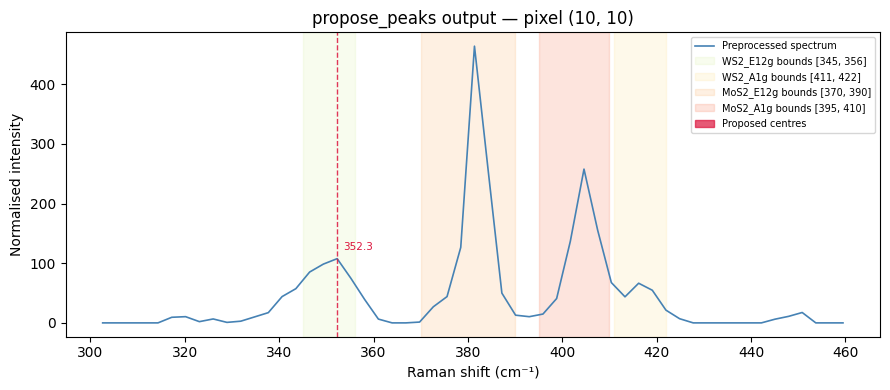

Proposal – window membership check:
  352.29 cm⁻¹  →  WS2_E12g


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from ramanpl.single_fit.initialisation import propose_peaks

# Reuse the cache and wavenumber axis populated in Snippet 1
spectrum   = raman_map._preprocessed_cube_cache[10, 10, :]
wavenumber = raman_map.wavenumber

proposals = propose_peaks(
    spectrum, wavenumber, n_peaks=4, prominence_rel=0.05, width_min_pts=3
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wavenumber, spectrum, color='steelblue', lw=1.2, label='Preprocessed spectrum')

# Shade the allowed fitting windows from custom_peaks
window_colours = ['#d9f0a3', '#fee08b', '#fdae61', '#f46d43']
for (name, (lb, ub)), col in zip(custom_peaks.items(), window_colours):
    ax.axvspan(lb[0], ub[0], alpha=0.18, color=col,
               label=f'{name} bounds [{lb[0]}, {ub[0]}]')

# Mark proposed centres with vertical dashed lines
for p in proposals:
    ax.axvline(p['centre'], color='crimson', lw=1.0, ls='--', alpha=0.85)
    ax.annotate(
        f"{p['centre']:.1f}",
        xy=(p['centre'], p['height']),
        xytext=(4, 6), textcoords='offset points',
        fontsize=7.5, color='crimson',
    )

proposal_patch = mpatches.Patch(color='crimson', alpha=0.7, label='Proposed centres')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [proposal_patch], fontsize=7, loc='upper right')
ax.set_xlabel('Raman shift (cm\u207b\u00b9)')
ax.set_ylabel('Normalised intensity')
ax.set_title('propose_peaks output — pixel (10, 10)')
plt.tight_layout()
plt.show()

# Check whether each proposal falls inside a bound window
print('Proposal \u2013 window membership check:')
for p in proposals:
    c = p['centre']
    matched = [name for name, (lb, ub) in custom_peaks.items() if lb[0] <= c <= ub[0]]
    status = matched[0] if matched else 'OUTSIDE ALL WINDOWS'
    print(f'  {c:6.2f} cm\u207b\u00b9  \u2192  {status}')

If a proposal reads `OUTSIDE ALL WINDOWS` it is either noise or a real spectral feature
not included in `custom_peaks`. Adjust `prominence_rel` upward to suppress weak detections,
or reduce `n_peaks` to limit the count. The proposal fallback inside the fitter applies
bounds-checking automatically, so an out-of-window proposal will never produce
an out-of-bounds p0.

---
## 3 — `p0_from_proposals` on a synthetic hard pixel

`p0_from_proposals` converts the output of `propose_peaks` into a revised initial-parameter
vector (`p0`) compatible with the Lorentzian or pseudo-Voigt fitter. It replaces the
centre and width in `p0` with proposal values, but **only where the proposed value lies
within the declared parameter bounds**. Parameters not improved by a proposal are left
unchanged from `current_p0`.

The synthetic spectrum below mimics the canonical hard case: two overlapping MoS₂ peaks
separated by only ~10 cm⁻¹, where the default midpoint p0 places the A₁g centre
far from its true position.

Proposals on synthetic hard pixel:
  centre=392.51 cm⁻¹  fwhm=8.53 cm⁻¹  height=0.8552
  centre=382.07 cm⁻¹  fwhm=3.28 cm⁻¹  height=0.6061

   Parameter      True  Default p0  Revised p0   Closer?
----------------------------------------------------------
 E12g centre    382.00      380.00      382.07         ✓
   E12g fwhm      6.00       10.00        1.64         -
    E12g amp      0.50        0.30        0.30         -
  A1g centre    392.00      402.50      402.50         -
    A1g fwhm      7.50       10.00        4.27         -
     A1g amp      0.80        0.30        0.30         -


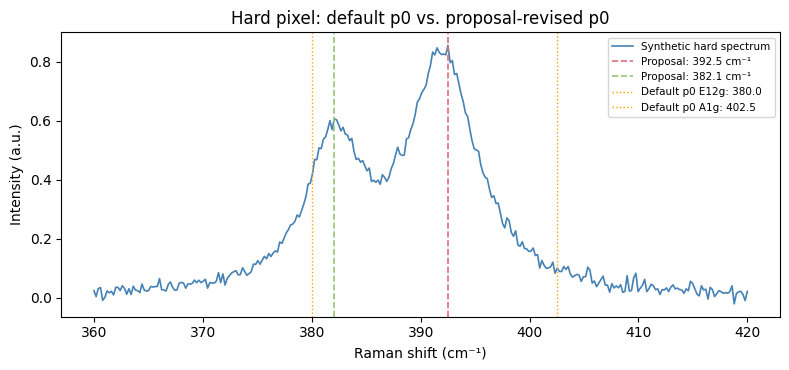

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ramanpl.single_fit.initialisation import propose_peaks, p0_from_proposals

# --- Synthetic hard pixel: two overlapping Lorentzian peaks ~10 cm⁻¹ apart ---
rng = np.random.default_rng(42)
wn  = np.linspace(360, 420, 300)   # wavenumber axis, cm⁻¹

def lorentzian(x, centre, fwhm, amp):
    g = fwhm / 2
    return amp * g**2 / ((x - centre)**2 + g**2)

# MoS2-like: E12g at 382 cm⁻¹, A1g at 392 cm⁻¹ (10 cm⁻¹ separation)
spec_hard = (
    lorentzian(wn, centre=382.0, fwhm=6.0, amp=0.50)
    + lorentzian(wn, centre=392.0, fwhm=7.5, amp=0.80)
    + rng.normal(0, 0.015, len(wn))
)

# Parameter layout for 2-peak Lorentzian: [c1, fwhm1, amp1, c2, fwhm2, amp2]
# Default p0: centres at midpoint of each bound window — A1g is ~10 cm⁻¹ off
p0_default = np.array([
    380.0, 10.0, 0.30,   # E12g: centre, fwhm, amplitude
    402.5, 10.0, 0.30,   # A1g:  centre far from true 392 cm⁻¹
])
bounds = (
    [370.0,  0.0, 0.0,   395.0,  0.0, 0.0],
    [390.0, 20.0, 1.4,   410.0, 20.0, 1.4],
)

# --- Run proposal on the hard spectrum ---
proposals = propose_peaks(
    spectrum=spec_hard, wavenumber=wn,
    n_peaks=2, prominence_rel=0.04, width_min_pts=3
)
print('Proposals on synthetic hard pixel:')
for p in proposals:
    print(f"  centre={p['centre']:.2f} cm\u207b\u00b9  fwhm={p['width']:.2f} cm\u207b\u00b9  height={p['height']:.4f}")

# --- Build revised p0 from proposals ---
p0_revised = p0_from_proposals(
    proposals    = proposals,
    peak_profile = 'lorentzian',
    current_p0   = p0_default,
    bounds       = bounds,
)

# --- Comparison table ---
param_names = ['E12g centre', 'E12g fwhm', 'E12g amp', 'A1g centre', 'A1g fwhm', 'A1g amp']
true_vals   = [382.0, 6.0, 0.50, 392.0, 7.5, 0.80]
print()
print(f"{'Parameter':>12}  {'True':>8}  {'Default p0':>10}  {'Revised p0':>10}  {'Closer?':>8}")
print('-' * 58)
for name, true, p0d, p0r in zip(param_names, true_vals, p0_default, p0_revised):
    tag = '\u2713' if abs(p0r - true) < abs(p0d - true) else ' -'
    print(f'{name:>12}  {true:>8.2f}  {p0d:>10.2f}  {p0r:>10.2f}  {tag:>8}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(wn, spec_hard, color='steelblue', lw=1.2, label='Synthetic hard spectrum')
colours = ['#e06c75', '#98c379']
for p, col in zip(proposals, colours):
    ax.axvline(p['centre'], color=col, lw=1.2, ls='--',
               label=f"Proposal: {p['centre']:.1f} cm\u207b\u00b9")
ax.axvline(p0_default[0], color='orange', lw=1.0, ls=':',
           label=f"Default p0 E12g: {p0_default[0]:.1f}")
ax.axvline(p0_default[3], color='orange', lw=1.0, ls=':',
           label=f"Default p0 A1g: {p0_default[3]:.1f}")
ax.set_xlabel('Raman shift (cm\u207b\u00b9)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Hard pixel: default p0 vs. proposal-revised p0')
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

**Key point:** For the A₁g peak, the default midpoint p0 is ~10 cm⁻¹ away from the true
position — a typical failure mode when two peaks overlap. `p0_from_proposals` moves the
A₁g centre close to 392 cm⁻¹, within the bounds window, giving `curve_fit` a much better
starting point.

FWHM and amplitude are not replaced here because the proposal width estimate carries
more uncertainty than the centre estimate. `p0_from_proposals` only replaces parameters
where the proposal is expected to be reliable. Any proposal value that falls outside
the declared bounds is silently ignored and `current_p0` is retained for that parameter.

---
## 4 — Mapping workflow: proposals on vs. off

In normal use the proposal fallback is **enabled by default** and invoked only for pixels
where the existing adaptive multistart has exhausted all retries. Pixels that succeed on
the normal path never reach the proposal code, so their output is bit-identical to v0.5.2.

Disable it via `fit_spectrum_kwargs` to reproduce the v0.5.2 behaviour or to run a
controlled before/after comparison.

In [9]:
from ramanpl import Mapping

custom_peaks = {
    'WS2_E12g'  : ([345, 0, 0], [356, 10, 70]),
    'WS2_A1g'   : ([417, 0, 0], [422, 10, 70]),
    'MoS2_E12g' : ([370, 0, 0], [390, 20, 140]),
    'MoS2_A1g'  : ([395, 0, 0], [410, 20, 140]),
}

def make_map():
    return Mapping.RamanMapping(
        'Mapping Raman Sample.wdf', custom_peaks,
        data_range=(300, 460),
        normalize=True, background_remove=True,
        baseline_method={"method": "arpls", "lam": 1e4, "niter": 250, "tol": 1e-6},
        smoothing=False, step_size=0.5,
    )

In [10]:
# --- Run 1: proposals disabled — reproduces v0.5.2 exactly ---
print('=' * 52)
print('Run 1  use_peak_proposals=False  (v0.5.2 baseline)')
print('=' * 52)
map_off = make_map()
map_off.fit_spectra(
    warm_start=True,
    seed_coord=(10, 10),
    fit_spectrum_kwargs=dict(use_peak_proposals=False),
)
map_off.fit_summary()

Run 1  use_peak_proposals=False  (v0.5.2 baseline)
Successful fits: 361 / 361

=== Fit summary ===
Successful fits: 361 / 361 (100.0%)
RMSE (fit-space): mean: 0.07125 | median: 0.05289 | q50: 0.05289 | q90: 0.1381 | q95: 0.2201 | q99: 0.2639

Bound-sticking (params at bounds per successful pixel):
  - lower: mean 0.837, max 4
  - upper: mean 0.978, max 5


{'n_total': 361,
 'n_ok': 361,
 'n_fail': 0,
 'success_rate': 1.0,
 'rmse_stats': {'mean': 0.07124717865251379,
  'median': 0.052885128571336766,
  'q50': 0.052885128571336766,
  'q90': 0.138094457216936,
  'q95': 0.22006378300030716,
  'q99': 0.26393333232987853},
 'failure_reasons': {},
 'bounds': {'lower': {'mean': 0.8365650969529086, 'max': 4},
  'upper': {'mean': 0.9778393351800554, 'max': 5}}}

In [11]:
# --- Run 2: proposals enabled — v0.5.3 default ---
print()
print('=' * 52)
print('Run 2  use_peak_proposals=True   (v0.5.3 default)')
print('=' * 52)
map_on = make_map()
map_on.fit_spectra(
    warm_start=True,
    seed_coord=(10, 10),
    # use_peak_proposals=True is the default; shown explicitly here for clarity
    fit_spectrum_kwargs=dict(use_peak_proposals=True),
)
map_on.fit_summary()


Run 2  use_peak_proposals=True   (v0.5.3 default)
Successful fits: 361 / 361

=== Fit summary ===
Successful fits: 361 / 361 (100.0%)
RMSE (fit-space): mean: 0.07124 | median: 0.05289 | q50: 0.05289 | q90: 0.1415 | q95: 0.2203 | q99: 0.2639

Bound-sticking (params at bounds per successful pixel):
  - lower: mean 0.834, max 3
  - upper: mean 1, max 6


{'n_total': 361,
 'n_ok': 361,
 'n_fail': 0,
 'success_rate': 1.0,
 'rmse_stats': {'mean': 0.07124247147445176,
  'median': 0.052885128574508784,
  'q50': 0.052885128574508784,
  'q90': 0.14152547610441618,
  'q95': 0.22034694672190577,
  'q99': 0.2639345004373642},
 'failure_reasons': {},
 'bounds': {'lower': {'mean': 0.8337950138504155, 'max': 3},
  'upper': {'mean': 1.002770083102493, 'max': 6}}}

**What to compare in `fit_summary()`:**

| Metric | Expected change |
|--------|-----------------|
| `Successful fits` | Equal or higher with proposals on |
| `RMSE mean/median` | Comparable or better; a large increase would indicate the fallback is being entered on pixels it should not reach |
| `Bound-sticking` | No systematic change expected for pixels that were already succeeding |

On this high-quality MoS₂/WS₂ dataset (100% success rate in v0.5.2) the counts will
be identical because the fallback is never triggered. The difference is visible on
noisier data or heterostructure regions with closely spaced or weak peaks.

---
## 5 — Identify rescued pixels

After fitting with proposals enabled, compare the `ok` column from `feature_table()`
between the two runs to identify which pixels were rescued by the fallback.
These pixels are worth inspecting individually with `plot_spectrum_fit()` to confirm
the fits are physically reasonable — a rescued fit with a high RMSE may still be
poor and should not be trusted without visual inspection.

This cell uses `map_off` and `map_on` from Snippet 4 — run that cell first.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build feature tables for both runs (coord_mode='pixel' for integer index access)
df_off = map_off.feature_table(coord_mode='pixel')
df_on  = map_on.feature_table(coord_mode='pixel')

# Merge on pixel coordinates to compare ok status side-by-side
merged = df_off[['x', 'y', 'ok', 'rmse']].merge(
    df_on[['x', 'y', 'ok', 'rmse']],
    on=['x', 'y'], suffixes=('_off', '_on')
)

# Rescued: failed without proposals, succeeded with proposals
rescued      = merged[(~merged['ok_off']) &  (merged['ok_on'])].copy()
# Regression check: should always be zero
newly_failed = merged[ (merged['ok_off']) & (~merged['ok_on'])].copy()

print(f"Pixels succeeded  — proposals OFF : {merged['ok_off'].sum():>4d}")
print(f"Pixels succeeded  — proposals ON  : {merged['ok_on'].sum():>4d}")
print(f"Rescued by fallback                : {len(rescued):>4d}")
print(f"Newly failed (regression check)    : {len(newly_failed):>4d}  \u2190 must be 0")

if len(rescued) > 0:
    # --- Spatial map of rescued pixels ---
    ok_off_map  = merged.pivot(index='y', columns='x', values='ok_off').astype(float)
    ok_on_map   = merged.pivot(index='y', columns='x', values='ok_on').astype(float)
    rescued_map = ok_on_map - ok_off_map   # 1.0 where pixel was rescued, 0.0 elsewhere

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, data, title in zip(
        axes,
        [ok_off_map, ok_on_map, rescued_map],
        ['ok map — proposals OFF', 'ok map — proposals ON', 'Rescued pixels (\u0394ok)']
    ):
        im = ax.imshow(data, cmap='RdYlGn', origin='upper', vmin=0, vmax=1)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('x (pixel index)')
        ax.set_ylabel('y (pixel index)')
        plt.colorbar(im, ax=ax, fraction=0.045)
    plt.suptitle('Fit success: before and after peak-proposal fallback', fontsize=10)
    plt.tight_layout()
    plt.show()

    # List rescued pixels ranked by post-rescue RMSE (highest = hardest, inspect first)
    print('\nRescued pixels ranked by post-rescue RMSE (inspect highest first):')
    print(rescued[['x', 'y', 'rmse_on']].sort_values('rmse_on', ascending=False).to_string(index=False))
else:
    print('\nNo pixels rescued on this dataset — the fallback was not needed.')
    print('Expected on high-quality maps. Run on noisier data to observe rescues.')

Pixels succeeded  — proposals OFF :  361
Pixels succeeded  — proposals ON  :  361
Rescued by fallback                :    0
Newly failed (regression check)    :    0  ← must be 0

No pixels rescued on this dataset — the fallback was not needed.
Expected on high-quality maps. Run on noisier data to observe rescues.


No rescued pixels. Inspecting reference pixel x=10, y=10.


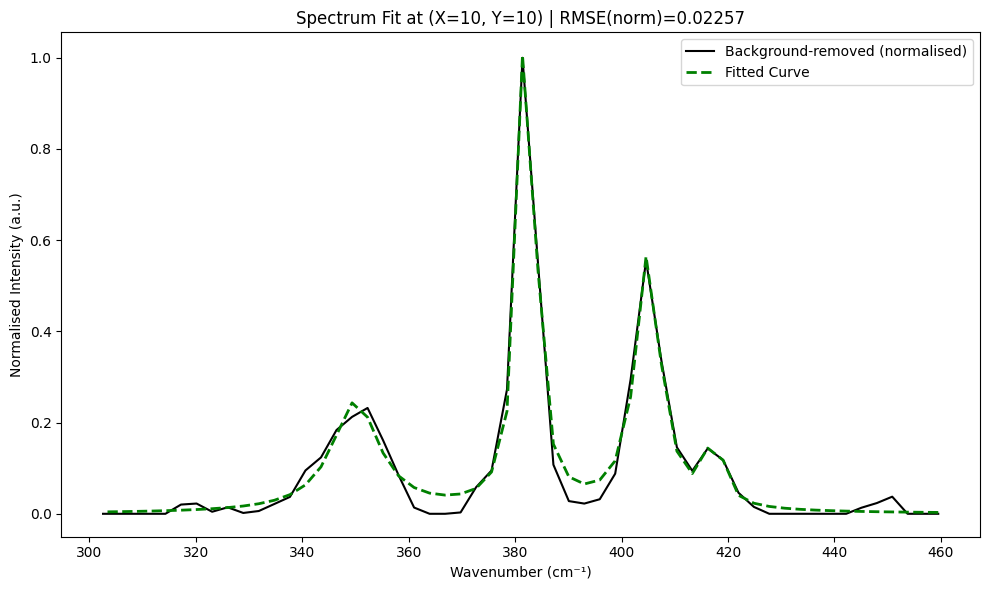

In [13]:
# --- Inspect the hardest rescued pixel visually ---
# If no pixels were rescued, any pixel coordinate works as a sanity check.

if len(rescued) > 0:
    # Highest post-rescue RMSE = hardest fit; inspect this one first
    worst = rescued.sort_values('rmse_on', ascending=False).iloc[0]
    x_inspect, y_inspect = int(worst['x']), int(worst['y'])
    print(f'Inspecting rescued pixel with highest RMSE: x={x_inspect}, y={y_inspect}')
    print(f'  RMSE after rescue  : {worst["rmse_on"]:.5f}')
    print(f'  Before rescue      : pixel had failed — no RMSE recorded')
else:
    x_inspect, y_inspect = 10, 10
    print(f'No rescued pixels. Inspecting reference pixel x={x_inspect}, y={y_inspect}.')

# plot_spectrum_fit shows the fitted curve overlaid on the preprocessed spectrum
map_on.plot_spectrum_fit(x=x_inspect, y=y_inspect)

---
## Summary

| Function / option | Role | Typical call site |
|---|---|---|
| `propose_peaks(spectrum, wavenumber, n_peaks, ...)` | Detect candidate centres and FWHM from a 1-D preprocessed spectrum via `scipy.signal.find_peaks` | Diagnostic; standalone inspection |
| `p0_from_proposals(proposals, peak_profile, current_p0, bounds)` | Convert proposals to a revised p0; bounds-checked, falls back to `current_p0` for any missing or out-of-bounds proposal | Same as above |
| `fit_spectrum_kwargs=dict(use_peak_proposals=True)` | Enable the automatic fallback (v0.5.3 default) — invoked only when all existing retries have failed | Normal mapping runs — no action needed |
| `fit_spectrum_kwargs=dict(use_peak_proposals=False)` | Disable the fallback — reproduces v0.5.2 behaviour exactly | Regression comparisons; debugging |

**Attribute reference:**

| Attribute | Type | Notes |
|-----------|------|-------|
| `raman_map.wavenumber` | 1-D array | Wavenumber axis in cm⁻¹; available before and after fitting |
| `raman_map._preprocessed_cube_cache` | 3-D array `(n_y, n_x, n_wn)` | Baseline-corrected spectra; populated by `fit_spectra()` |
| `raman_map.spectra` | 3-D array | Raw (unprocessed) spectra from the `.wdf` file |

---
> **Scientific note:** The proposal fallback does not change the fitting model or the
> optimisation algorithm. It provides a better starting point (`p0`) for
> `scipy.optimize.curve_fit` on pixels that would otherwise be marked failed.
> All reported peak parameters remain the output of deterministic Lorentzian or
> pseudo-Voigt least-squares fitting — traceable to the same physical model as all
> prior builds.